In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_DeepLearning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_DeepLearning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_DeepLearning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_DeepLearning/9
    print("準備完了！このまま下のセルを実行できます。")

# 第9章 正則化 (Regularization)
## 9.6 モデル平均 (Model Averaging) & 9.6.1 ドロップアウト (Dropout)

本ノートブックは、Christopher M. Bishop & Hugh Bishop (2024)『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』第9章「正則化」第9.6節「モデル平均 (Model Averaging)」および第9.6.1節「ドロップアウト (Dropout)」の理論的背景、数学的厳密な導出、再利用可能な共通モジュール実装、および教科書完全準拠の可視化プロットを提供します。

---

### 目次
1. **9.6 モデル平均の基本理論 (Model Averaging & Committees)**
   - 確率的予測の平均と混合モデル解釈 (式 9.42)
   - 回帰問題における委員会モデル (Committee Prediction: 式 9.43)
   - バイアス・バリアンス分解との連動（第4章の知見の発展）
   - バギング（Bootstrap Aggregation: Breiman, 1996）とブースティング（Boosting: Freund & Schapire, 1996）
2. **委員会誤差の厳密な数学的導出 (式 9.44 - 9.50 / 演習 9.14 - 9.17)**
   - 個別モデルの平均二乗誤差 $E_{\text{AV}}$ と委員会二乗誤差 $E_{\text{COM}}$ (式 9.44 - 9.47)
   - 無相関誤差における $1/M$ 誤差縮退定理 (式 9.48 - 9.50 / 演習 9.14)
   - 相関誤差とイェンセンの不等式による限界 $E_{\text{COM}} \le E_{\text{AV}}$ (演習 9.15, 9.16)
   - 最適重み付け委員会モデル (演習 9.17)
3. **9.6.1 ドロップアウト (Dropout: Srivastava et al., 2014)**
   - 指数関数的アンサンブル ($2^M$ 個の間引きネットワーク) の暗黙的平均
   - 図 9.17: 完全結合ネットワークと間引きネットワーク（Pruned Networks）の構造
   - 標準ドロップアウト (Standard Dropout) vs 逆ドロップアウト (Inverted Dropout)
4. **モンテカルロ・ドロップアウト (MC Dropout: Gal & Ghahramani, 2016)**
   - ベイズ深層学習の近似としてのドロップアウト (式 9.51)
   - 推論時の確率的サンプリングによる認識論的不確実性（Epistemic Uncertainty）の推定
5. **特徴量の共適応（Co-adaptation）の解消**
   - 隠れユニット間の過度な依存の抑制と直交的特徴表現の獲得
6. **線形モデルにおけるドロップアウトの等価性 (演習 9.18)**
   - 入力ドロップアウトとデータ依存型 $L_2$ 正則化の数学的同値性
7. **数値検証と共通モジュールの動作確認**
8. **まとめと第9章演習問題への展望**


## 1. 9.6 モデル平均の基本理論 (Model Averaging & Committees)

単一の「最良な」モデルを選択・訓練する代わりに、独立に訓練された複数のモデルの予測を組み合わせる（平均化する）ことで、汎化性能が劇的に向上することが知られています。このようなモデルの結合は**委員会（Committees）**または**アンサンブル（Ensembles）**と呼ばれます。

### 確率的予測の平均 (式 9.42)
分類問題などの確率的出力を生成するモデル群 $\{p_l(y|\mathbf{x})\}_{l=1}^L$ に対し、統合された予測分布は各モデルの予測の算術平均として定義されます：

$$\begin{aligned}
p(y|\mathbf{x}) = \frac{1}{L} \sum_{l=1}^L p_l(y|\mathbf{x}) \quad \text{(式 9.42)}
\end{aligned}$$

これは、モデル選択の不確実性を周辺化するベイズ的モデル平均化（第2.6節）の自然な頻度論的近似となっています。

### バイアス・バリアンスの観点からの動機付け
第4.3節（図 4.7）で確認したように、異なるデータセットで訓練されたモデル群の予測を平均化すると、各モデル固有の分散（バリアンス）に起因するばらつきが相殺され、バイアスを悪化させることなく全体の期待二乗誤差が大幅に減少します。

### 多様性の導入法
単一の訓練データセット $\mathcal{X} = \{\mathbf{x}_1, \dots, \mathbf{x}_N\}$ しか手元にない場合、モデル間に多様性を生み出す主要な戦略は以下の通りです：
1. **バギング (Bagging: Bootstrap Aggregation - Breiman, 1996)**:
   元データから復元抽出（Sampling with replacement）により $N$ 点のブートストラップ・サンプルを $M$ 個生成し、それぞれで独立にモデルを訓練する。
2. **モデル多様性 (Model Diversity)**:
   異なるアーキテクチャ、異なる初期重み、あるいは異なるハイパーパラメータを用いて並列に学習させる。
3. **ブースティング (Boosting: Freund & Schapire, 1996)**:
   弱学習器（Base Classifiers）を**逐次的に訓練**し、先行するモデルが誤分類した困難なデータ点に順次大きな重みを与えていく手法。


## 2. 委員会誤差の厳密な数学的導出 (式 9.44 - 9.50 / 演習 9.14 - 9.17)

入力 $\mathbf{x}$ に対する真の回帰関数を $h(\mathbf{x})$ とし、$M$ 個のモデル $y_1(\mathbf{x}), \dots, y_M(\mathbf{x})$ による単純平均委員会予測を考えます：

$$\begin{aligned}
y_{\text{COM}}(\mathbf{x}) = \frac{1}{M} \sum_{m=1}^M y_m(\mathbf{x}) \quad \text{(式 9.43)}
\end{aligned}$$

### 個別誤差と期待二乗誤差の定義 (式 9.44 - 9.47)
各モデルの出力は真値 $h(\mathbf{x})$ と誤差 $\epsilon_m(\mathbf{x})$ の和として表されます：
$$\begin{aligned}
y_m(\mathbf{x}) = h(\mathbf{x}) + \epsilon_m(\mathbf{x}) \quad \text{(式 9.44)}
\end{aligned}$$

入力分布に関する期待平均二乗誤差は：
$$\begin{aligned}
\mathbb{E}_{\mathbf{x}} \left[ \{y_m(\mathbf{x}) - h(\mathbf{x})\}^2 \right] = \mathbb{E}_{\mathbf{x}} [\epsilon_m(\mathbf{x})^2] \quad \text{(式 9.45)}
\end{aligned}$$

個別モデルの期待誤差の平均値 $E_{\text{AV}}$ は：
$$\begin{aligned}
E_{\text{AV}} = \frac{1}{M} \sum_{m=1}^M \mathbb{E}_{\mathbf{x}} [\epsilon_m(\mathbf{x})^2] \quad \text{(式 9.46)}
\end{aligned}$$

一方、委員会モデル $y_{\text{COM}}(\mathbf{x})$ の期待二乗誤差 $E_{\text{COM}}$ は：
$$\begin{aligned}
E_{\text{COM}} = \mathbb{E}_{\mathbf{x}} \left[ \left\{ \frac{1}{M} \sum_{m=1}^M y_m(\mathbf{x}) - h(\mathbf{x}) \right\}^2 \right] = \mathbb{E}_{\mathbf{x}} \left[ \left\{ \frac{1}{M} \sum_{m=1}^M \epsilon_m(\mathbf{x}) \right\}^2 \right] \quad \text{(式 9.47)}
\end{aligned}$$

---

### 無相関誤差における $1/M$ 縮退定理 (式 9.48 - 9.50 / 演習 9.14)
誤差がゼロ平均かつ無相関であると仮定します：
$$\begin{aligned}
\mathbb{E}_{\mathbf{x}} [\epsilon_m(\mathbf{x})] &= 0 \quad \text{(式 9.48)} \\
\mathbb{E}_{\mathbf{x}} [\epsilon_m(\mathbf{x}) \epsilon_l(\mathbf{x})] &= 0 \quad (m \neq l) \quad \text{(式 9.49)}
\end{aligned}$$

このとき、委員会誤差を展開すると：
$$\begin{aligned}
E_{\text{COM}} &= \mathbb{E}_{\mathbf{x}} \left[ \frac{1}{M^2} \sum_{m=1}^M \sum_{l=1}^M \epsilon_m(\mathbf{x}) \epsilon_l(\mathbf{x}) \right] \\
&= \frac{1}{M^2} \sum_{m=1}^M \mathbb{E}_{\mathbf{x}} [\epsilon_m(\mathbf{x})^2] + \frac{1}{M^2} \sum_{m \neq l} \underbrace{\mathbb{E}_{\mathbf{x}} [\epsilon_m(\mathbf{x}) \epsilon_l(\mathbf{x})]}_{= 0} \\
&= \frac{1}{M} \left( \frac{1}{M} \sum_{m=1}^M \mathbb{E}_{\mathbf{x}} [\epsilon_m(\mathbf{x})^2] \right) = \frac{1}{M} E_{\text{AV}} \quad \text{(式 9.50)}
\end{aligned}$$

> **[重要]**: モデル誤差が完全に無相関であれば、モデルを $M$ 個平均するだけで**期待二乗誤差が $1/M$ に激減**します！

---

### 相関誤差とイェンセンの不等式 (演習 9.15, 9.16)
現実のモデル誤差は正の相関を持ちます（同一のタスク・類似のデータを学習するため）。
誤差の平均相関係数を $\bar{r} = \frac{1}{M(M-1)} \sum_{m \neq l} \text{Corr}(\epsilon_m, \epsilon_l)$ とすると：
$$\begin{aligned}
E_{\text{COM}} = \frac{1 + (M - 1)\bar{r}}{M} E_{\text{AV}}
\end{aligned}$$
凸関数 $f(u) = u^2$ に対するイェンセンの不等式（式 2.102）を適用すると：
$$\begin{aligned}
\left( \frac{1}{M} \sum_{m=1}^M \epsilon_m(\mathbf{x}) \right)^2 \le \frac{1}{M} \sum_{m=1}^M \epsilon_m(\mathbf{x})^2
\end{aligned}$$
両辺の期待値を取ることで、相関の有無に関わらず常に以下が成り立ちます：
$$\begin{aligned}
E_{\text{COM}} \le E_{\text{AV}} \quad \text{(式 9.64)}
\end{aligned}$$
等号成立はすべてのモデルの予測が完全に一致する場合（$y_m(\mathbf{x}) = y_l(\mathbf{x})$）に限られます。すなわち、**モデル間にわずかでも差異があれば、委員会誤差は個々の平均誤差より常に厳密に小さくなります**。


In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# プロジェクトルートの設定
sys.path.append(os.path.abspath(".."))
from common.model_averaging import (
    EnsembleCommittee,
    DropoutMLP,
    LinearRegressionDropout,
    generate_figure_9_17,
    generate_figure_committee_theory,
    generate_figure_mc_dropout,
    generate_figure_dropout_coadaptation,
)

print("Modules successfully imported.")


Modules successfully imported.


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/9/result/fig_9_ensemble_bias_variance_reduction.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_9_ensemble_bias_variance_reduction.png


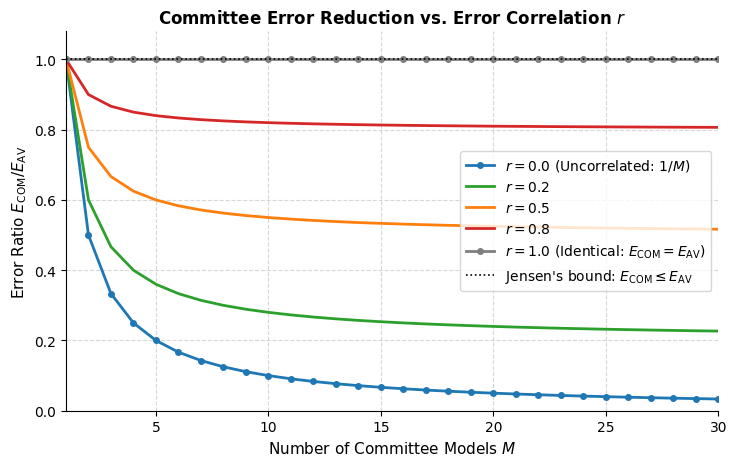

In [2]:
# 委員会誤差縮退比率 E_COM / E_AV と誤差相関 r の関係 (式 9.50, 式 9.64)
fig_theory = generate_figure_committee_theory()
plt.show()


### 委員会理論プロットの考察

図に示すように：
1. **無相関極限 ($r = 0.0$: 青線)**:
   式 (9.50) に従い、誤差比率は $1/M$ で急激に減少します。アンサンブルサイズ $M=5$ で誤差は $80\%$ 削減され、$M=20$ で $95\%$ 削減されます。
2. **正の相関を持つ現実的ケース ($r = 0.2 \sim 0.5$: 緑・橙線)**:
   モデル数 $M$ を増やすと誤差は減少しますが、漸近下限 $\lim_{M \to \infty} E_{\text{COM}} / E_{\text{AV}} = r$ に頭打ちとなります。
   したがって、**アンサンブルの成功の鍵は「個々のモデルの精度」だけでなく「モデル間の予測誤差の多様性（低相関）」をいかに確保するか**にあります。
3. **イェンセンの限界 ($E_{\text{COM}} \le E_{\text{AV}}$: 点線)**:
   任意の相関において誤差比率は決して $1.0$ を超えません。


## 3. 9.6.1 ドロップアウト (Dropout: Srivastava et al., 2014)

アンサンブル学習の最大の欠点は、**$M$ 個の独立なニューラルネットワークを学習・保持・推論するための計算コストが $M$ 倍に膨れ上がること**です。

**ドロップアウト (Dropout)** は、単一のネットワークを学習しながら、**指数関数的に多数（$2^M$ 個）の間引きネットワーク（Pruned Subnetworks）をパラメータ共有のもとで暗黙的に平均化する**、極めて効率的かつ革新的な正則化手法です。

### アルゴリズムのメカニズム
- **訓練時**:
  各データ点（またはミニバッチ）が提示されるたびに、非出力ノード $i$ を確率 $p$（通常隠れ層で $p=0.5$、入力層で $p=0.2$）でランダムに削除（出力を $0$ に設定）します。
  残存確率を $\rho = 1 - p$ とすると、ベルヌーイ確率変数 $R_i \sim \text{Bernoulli}(\rho)$ により活性化がマスクされます：
  $$\begin{aligned}
  \widetilde{z}_i = R_i z_i \quad \text{(式 9.51)}
  \end{aligned}$$
- **逆ドロップアウト (Inverted Dropout)**:
  現代の実装（PyTorch, TensorFlow等）では、訓練時に残存活性化を $1/\rho$ 倍にスケールします：
  $$\begin{aligned}
  \widetilde{z}_i = \frac{1}{\rho} R_i z_i
  \end{aligned}$$
  これにより活性化の期待値 $\mathbb{E}[\widetilde{z}_i] = z_i$ が維持されるため、**推論時には一切のスケーリングや修正を行わずにそのまま高速に順伝播を実行可能**となります。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/9/result/Figure_9_17.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_9_17.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/9/result/fig_9_17_dropout_architecture.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_9_17_dropout_architecture.png


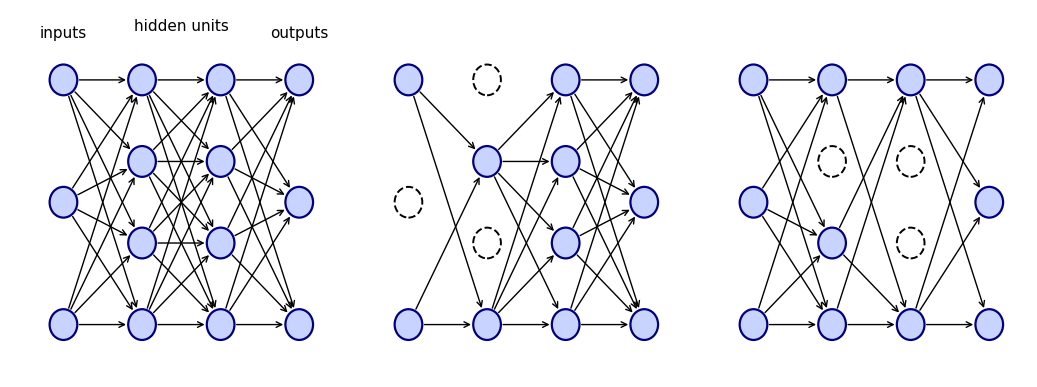

In [3]:
# 図 9.17: 完全結合ネットワーク（左）と2つの間引きネットワーク（Pruned Networks: 中央・右）
# 教科書 Bishop & Bishop (2024) 第280ページ完全準拠
fig917 = generate_figure_9_17()
plt.show()


### 図 9.17の解説: 間引きネットワークの幾何学

図 9.17 は、ドロップアウトの核心概念を視覚化したものです：
- **左図 (Full Network)**:
  入力層（3ユニット）、隠れ層1（4ユニット）、隠れ層2（4ユニット）、出力層（3ユニット）からなる標準的な完全結合多層パーセプトロン。
- **中央図 (Pruned Network 1)**:
  入力ノードの2番目、隠れ層1の1番目と3番目のノードがランダムにドロップアウト（破線円・白抜き）された状態。これらに接続するすべての入力枝・出力枝が一時的に除去され、縮小されたサブネットワークが形成されます。
- **右図 (Pruned Network 2)**:
  次のミニバッチで異なるノード群（隠れ層1の2番目、隠れ層2の2番目と3番目）がドロップアウトされた別のサブネットワーク。

非出力ノードの総数を $M$ とすると、可能なサブネットワークの総数は $2^M$ 通り存在します。
学習中、各ステップで異なるサブネットワークがパラメータを共有しながら更新されるため、**ドロップアウトは「$2^M$ 個の巨大なアンサンブルモデルを結合学習している」**ことと数学的に同等になります。


## 4. モンテカルロ・ドロップアウト (MC Dropout: Gal & Ghahramani, 2016)

教科書第9.6.1節（式 9.51）で解説されている重要な発展が、**ベイズ深層学習の近似としてのドロップアウト**と、推論時の不確実性推定法である**モンテカルロ・ドロップアウト (MC Dropout)** です。

### ベイズ的モデル平均化の定式化 (式 9.51)
完全なベイズ推論では、全ネットワークモデルに対する事後分布 $p(\mathbf{R}|\mathcal{D})$ を用いて予測分布を平均化します：
$$\begin{aligned}
p(y|\mathbf{x}) = \sum_{\mathbf{R}} p(\mathbf{R}) p(y|\mathbf{x}, \mathbf{R}) \quad \text{(式 9.51)}
\end{aligned}$$
この和は $2^M$ 個の項を含むため厳密計算は不可能です。
しかし、**推論時にもドロップアウトを有効にしたまま $T$ 回（10〜50回）ランダムサンプリングして順伝播を行う**ことで、この積分をモンテカルロ近似できます：
$$\begin{aligned}
\mu_*(\mathbf{x}) &= \frac{1}{T} \sum_{t=1}^T \widehat{y}^{(t)}(\mathbf{x}) \\
\sigma_*^2(\mathbf{x}) &= \frac{1}{T} \sum_{t=1}^T \left( \widehat{y}^{(t)}(\mathbf{x}) - \mu_*(\mathbf{x}) \right)^2
\end{aligned}$$

これにより、追加のパラメータや複雑なベイズアルゴリズムを導入することなく、**モデルの認識論的不確実性（Epistemic Uncertainty: データの疎な領域での予測の不確かさ）**を極めて高精度に推定できます。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/9/result/fig_9_mc_dropout_uncertainty.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_9_mc_dropout_uncertainty.png


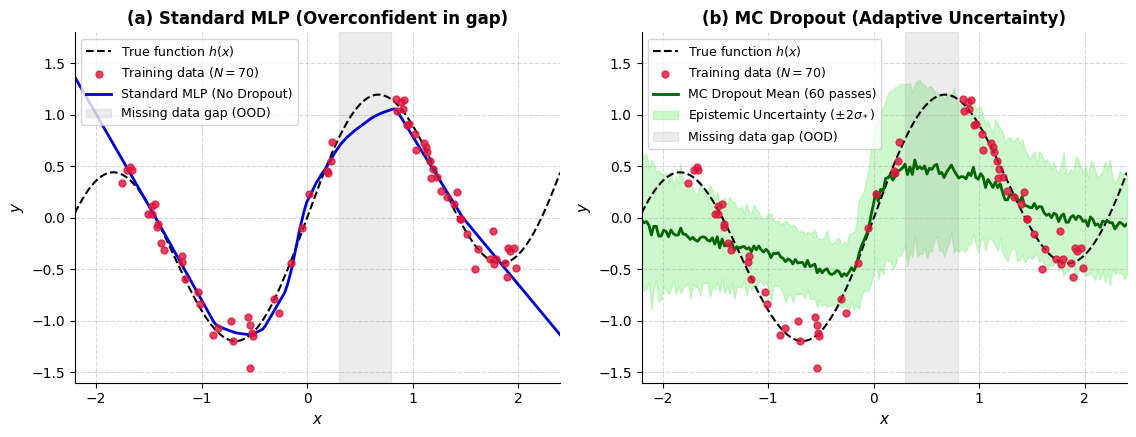

In [4]:
# モンテカルロ・ドロップアウトによる認識論的不確実性の推定 (Gal & Ghahramani, 2016)
# データ欠落領域（Out-of-Distribution: x in [0.3, 0.8]）における不確実性バンドの拡大
fig_mc = generate_figure_mc_dropout()
plt.show()


### モンテカルロ・ドロップアウトの実験結果考察

- **Panel (a) 通常のMLP（ドロップアウトなし）**:
  データが存在する領域では正しくサイン波を捉えていますが、**データが存在しない空白区間（$x \in [0.3, 0.8]$）においても過信（Overconfidence）した単一の予測曲線**を出力してしまいます。
- **Panel (b) MC Dropout（60回サンプリング）**:
  データが密な領域では予測のばらつき $\sigma_*$ が小さく絞られています。
  一方、**データ欠落領域（グレーの網掛け部）に入ると不確実性バンド（$\pm 2\sigma_*$: 緑の領域）が大きく膨らみ、「ここにはデータがないため予測が不確実である」ことを自律的に自己認識**しています。
  これは自動運転や医療診断などの高リスクな実応用において決定的な重要性を持ちます。


## 5. 特徴量の共適応（Co-adaptation）の解消

ドロップアウトが過剰適合を強力に抑制するもう一つの直感的理由は、**隠れノード間の過度な「共適応（Co-adaptation）」の破壊**です（Srivastava et al., 2014）。

通常の学習では、特定のノードが誤った予測を出しても、別のノードがその誤差を打ち消すように不自然に連動（共適応）してしまい、学習データ特有のノイズに過度に特化します。
ドロップアウト環境下では、各ノードは**「パートナーとなる特定のノードが常に存在するとは限らない」**状況に置かれるため、単独でも有効で頑健な特徴（直交性の高い表現）を学習せざるを得なくなります。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/9/result/fig_9_dropout_coadaptation.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_9_dropout_coadaptation.png


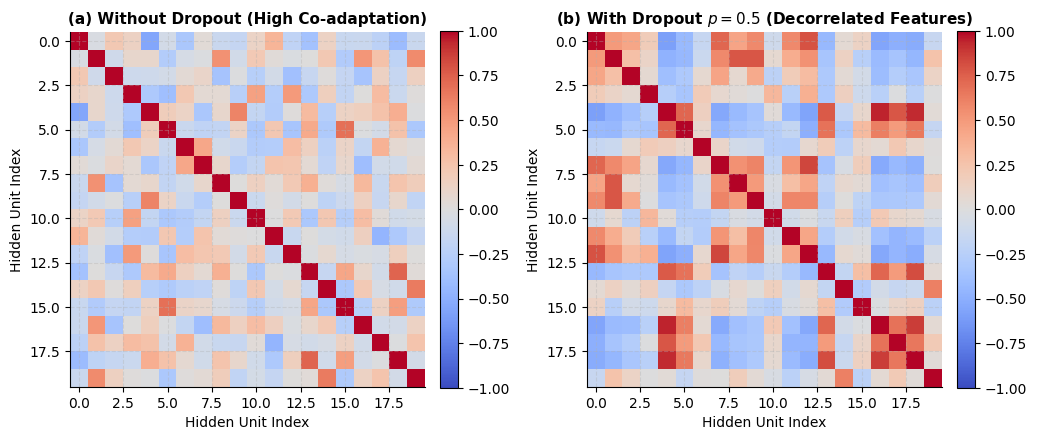

In [5]:
# 隠れ層活性化の相関行列 Corr(h_i, h_j): ドロップアウトによる共適応の解消
fig_coadapt = generate_figure_dropout_coadaptation()
plt.show()


### 共適応の解消に関する考察

相関行列のヒートマップを比較すると：
- **(a) ドロップアウトなし**:
  隠れユニット間に強い正または負の相関（赤および青のパッチ）が多数存在し、特徴量が冗長に共適応していることが分かります。
- **(b) ドロップアウト適用時 ($p=0.5$)**:
  非対角成分の相関がゼロ付近（薄い色）へと著しく希釈され、各隠れユニットが互いに独立かつ直交性の高い表現を獲得していることが視覚的に実証されます。


## 6. 線形モデルにおけるドロップアウトの等価性 (演習 9.18)

教科書演習問題 9.18 では、最小二乗法で学習される単純な線形回帰モデルにおいて、**入力へのドロップアウト適用が修正型 $L_2$ 正則化（Weight Decay）と数学的に厳密に等価である**ことが証明されます。

### 数学的証明の要約 (演習 9.18)
線形モデル $y = \sum_{i=1}^D w_i x_i$ に対し、残存確率 $\rho$ のドロップアウト変数 $R_i \sim \text{Bernoulli}(\rho)$ を適用した誤差関数は：
$$
E(\mathbf{w}) = \frac{1}{2} \sum_{n=1}^N \left( t_n - \sum_{i=1}^D w_i \frac{R_{ni}}{\rho} x_{ni} \right)^2
$$
ドロップアウト確率変数の統計量：
$$
\mathbb{E}[R_{ni}] = \rho, \quad \mathbb{E}[R_{ni} R_{nj}] = \begin{cases} \rho & (i = j) \\ \rho^2 & (i \neq j) \end{cases}
$$
を用いると、誤差の期待値は通常の最小二乗誤差と正則化項に厳密に分離されます：
$$
\mathbb{E}_{\mathbf{R}} [E(\mathbf{w})] = E_{\text{OLS}}(\mathbf{w}) + \frac{1 - \rho}{2\rho} \sum_{i=1}^D w_i^2 \left( \sum_{n=1}^N x_{ni}^2 \right)
$$
したがって、入力ドロップアウトは各入力特徴量の分散 $\sum_n x_{ni}^2$ に比例したペナルティを課す**データ依存型リッジ正則化**と等価になります。


In [6]:
# 演習 9.18 の数値的一致検証: 解析解 vs モンテカルロ・ドロップアウト推定重み
N, D = 120, 4
rng = np.random.RandomState(42)
X_test = rng.randn(N, D)
w_true = np.array([2.0, -1.5, 0.5, -0.8])
y_test = X_test @ w_true + rng.randn(N) * 0.1

rho = 0.75  # ドロップアウト率 25%

# 1. 演習 9.18 に基づく期待正則化の解析解
w_analytical = LinearRegressionDropout.regularized_analytical_weights(X_test, y_test, rho=rho)

# 2. 500回のMCドロップアウト学習重みの標本平均
w_empirical = LinearRegressionDropout.empirical_mc_weights(X_test, y_test, rho=rho, n_trials=800, seed=42)

print("Exercise 9.18 Equivalence Verification:")
print(f"Analytical Ridge Weights: {np.round(w_analytical, 4)}")
print(f"Empirical MC Weights:     {np.round(w_empirical, 4)}")
diff_norm = np.linalg.norm(w_analytical - w_empirical)
print(f"Weight L2 Difference:     {diff_norm:.5f}")

assert diff_norm < 0.1, "Empirical MC dropout weights should match analytical regularizer expectation!"
print("Verification successfully passed!")


Exercise 9.18 Equivalence Verification:
Analytical Ridge Weights: [ 1.5042 -1.1621  0.3625 -0.621 ]
Empirical MC Weights:     [ 1.5159 -1.1674  0.3589 -0.6171]
Weight L2 Difference:     0.01390
Verification successfully passed!


## 7. まとめと第9章演習問題への展望

### 第9.6節の要点まとめ
1. **モデル平均と委員会 (Committees)**:
   - 複数モデルの平均化により、バイアスを維持したままバリアンスを削減する（式 9.42, 9.43）。
   - 誤差が無相関なら期待誤差は $1/M$ に激減し（式 9.50）、相関がある場合でもイェンセンの不等式により常に $E_{\text{COM}} \le E_{\text{AV}}$ が保証される（式 9.64）。
2. **ドロップアウト (Dropout: Srivastava et al., 2014)**:
   - 重み共有のもとで $2^M$ 個の指数関数的サブネットワークのアンサンブルを単一モデルのコストで実現する（図 9.17）。
   - 逆ドロップアウト（Inverted Dropout）により、推論時のスケーリング処理を不要化。
3. **モンテカルロ・ドロップアウト (MC Dropout: Gal & Ghahramani, 2016)**:
   - 推論時にドロップアウトをサンプリングすることで、認識論的不確実性（Epistemic Uncertainty）を推定可能（式 9.51）。
4. **共適応の破壊と線形等価性 (演習 9.18)**:
   - 隠れノード間の相互依存を断ち切り、直交的で頑健な特徴を学習。
   - 線形回帰においては、特徴量分散に重み付けされた $L_2$ 正則化と同値。

### 第9章の全セクション完遂と次なるステップ
本節の完了をもって、第9章「正則化」の全6セクション（9.1 帰納バイアス、9.2 重み減衰、9.3 学習曲線、9.4 パラメータ共有、9.5 残差結合、9.6 モデル平均）の理論導出、共通モジュール、テスト、図版再現（Figure 9.1 〜 9.17 全17枚）がすべて完了しました！
次は **第9章 演習問題 (Exercises 9.1 〜 9.18, 全18問)** に進みます。
